# Homework 5: Neural Networks with Keras (Census / Adult Dataset)

**Advanced Machine Learning**

Predict whether annual income is **>50K** using the UCI Adult dataset.

This notebook follows the course assignment: baseline MLP → controlled experiments (architecture, epochs, dropout) → **Optuna** tuning → final model on a **held-out test set**, with conclusions supported by metrics and train/validation curves. Preprocessing reuses Week 4 adult handling and Week 7 Keras patterns (`Inclass_05_14`).


In [15]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

tf.random.set_seed(42)
np.random.seed(42)


## 1. Load and prepare data


In [16]:
adult = pd.read_csv("adult.csv")
adult = adult.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
adult = adult.replace("?", np.nan)
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)
adult.drop(columns=["fnlwgt"], inplace=True)
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)

# Coerce numeric columns (may be string dtype after strip / read_csv)
for col in ["age", "educational-num", "capital-gain", "capital-loss", "hours-per-week"]:
    adult[col] = pd.to_numeric(adult[col], errors="coerce")

for col in adult.columns:
    if pd.api.types.is_numeric_dtype(adult[col]):
        adult[col] = adult[col].fillna(adult[col].median())
    else:
        adult[col] = adult[col].fillna("unknown")
adult.head()


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,unknown,Some-college,10,Never-married,unknown,Own-child,White,0,0,0,30,United-States,0


In [17]:
df = adult.copy()
df.drop(columns=["education"], inplace=True)
X = df.drop(columns=["income"])
y = df["income"]

numeric_features = [
    "age", "educational-num", "capital-gain", "capital-loss", "hours-per-week", "gender"
]
categorical_features = [c for c in X.columns if c not in numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ]
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)
n_features = X_train_scaled.shape[1]
print("Train:", X_train_scaled.shape, "| Test:", X_test_scaled.shape, "| Features:", n_features)


Train: (39073, 90) | Test: (9769, 90) | Features: 90


## 2. Baseline neural network

Two hidden layers (64 → 32), ReLU activations, sigmoid output for binary classification.


### Build the model


In [18]:
tf.random.set_seed(42)

inputs = keras.Input(shape=(n_features,))
x = layers.Dense(64, activation="relu")(inputs)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 90)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         5,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,937 (31.00 KB)

 Trainable params: 7,937 (31.00 KB)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)


In [19]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(
    X_train_scaled,
    y_train,
    batch_size=256,
    epochs=30,
    validation_split=0.2,
    verbose=1,
)

scores = model.evaluate(X_test_scaled, y_test, verbose=1)


Epoch 1/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8147 - loss: 0.3941 - val_accuracy: 0.8485 - val_loss: 0.3237
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8528 - loss: 0.3137 - val_accuracy: 0.8505 - val_loss: 0.3165
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8563 - loss: 0.3075 - val_accuracy: 0.8518 - val_loss: 0.3149
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8576 - loss: 0.3044 - val_accuracy: 0.8517 - val_loss: 0.3143
Epoch 5/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8582 - loss: 0.3023 - val_accuracy: 0.8530 - val_loss: 0.3141
Epoch 6/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8591 - loss: 0.3007 - val_accuracy: 0.8530 - val_loss: 0.3142
Epoch 7/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8597 - loss: 0.2993 - val_accuracy: 0.8532 - val_loss: 0.3143
Epoch 8/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8603 - loss: 0.2979 - val_accuracy: 0.

### Evaluating model training using loss and accuracy


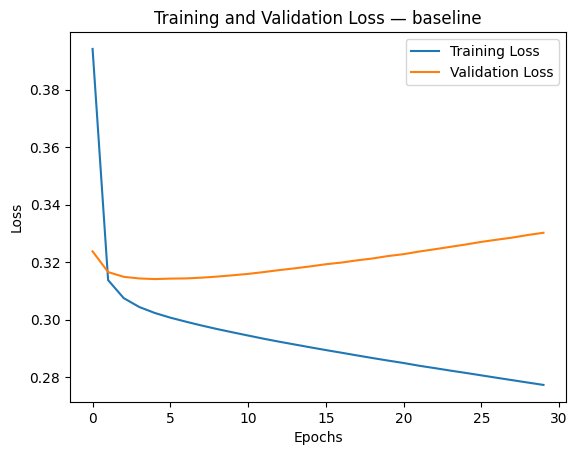

In [20]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss — baseline")
plt.legend()
plt.show()


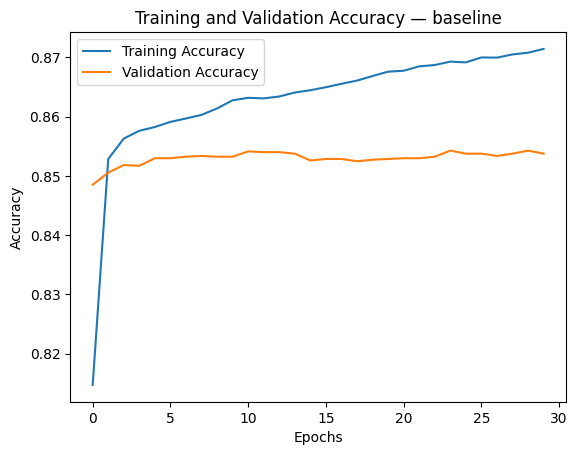

In [21]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy — baseline")
plt.legend()
plt.show()


### Evaluating on the test data


In [22]:
y_pred_prob = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nBaseline Test Set Evaluation:")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Test F1 Score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Test ROC AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")



Baseline Test Set Evaluation:
Test Accuracy: 0.8589
Test Precision: 0.7395
Test Recall: 0.6339
Test F1 Score: 0.6826
Test ROC AUC Score: 0.9091


## 3. Experiments — change one factor at a time

Each block varies **one** factor while holding fixed: `random_state=42`, Adam optimizer, `batch_size=256`, `validation_split=0.2`, and (except in §3a) architecture `[64, 32]`. Test metrics below are on the **held-out test set** after each short training run.


### 3a. Factor: architecture (10 epochs each)

Same training setup as baseline except hidden-layer widths/depth; **10 epochs** only (fair comparison at equal training time).


baseline [64, 32] {'architecture': 'baseline [64, 32]', 'accuracy': 0.8579179035725253, 'f1': 0.6795937211449676, 'roc_auc': 0.9116074328072616}
wider [128, 128] {'architecture': 'wider [128, 128]', 'accuracy': 0.8612959361244754, 'f1': 0.6819995306266134, 'roc_auc': 0.9119459621618404}
deeper funnel [128, 64, 32] {'architecture': 'deeper funnel [128, 64, 32]', 'accuracy': 0.8591462790459617, 'f1': 0.6808905380333952, 'roc_auc': 0.9126097248953273}


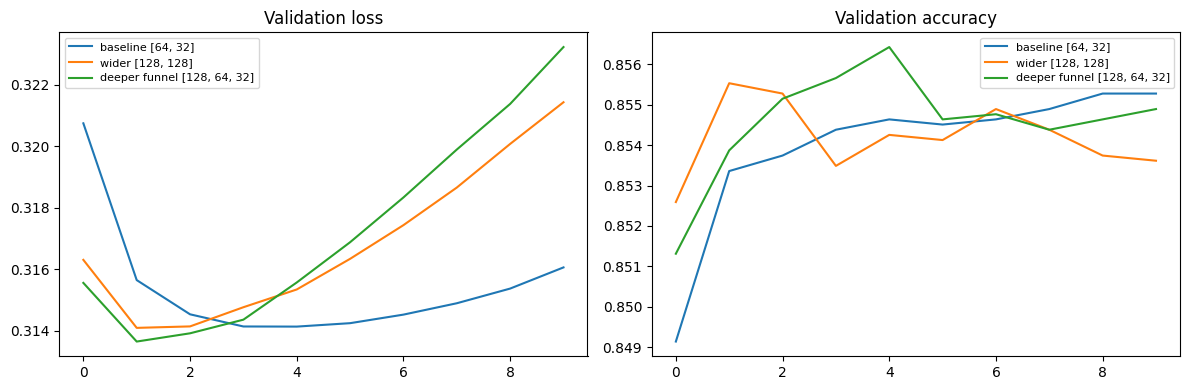

,architecture,accuracy,f1,roc_auc
2,"deeper funnel [128, 64, 32]",0.859146,0.680891,0.912610
1,"wider [128, 128]",0.861296,0.682000,0.911946
0,"baseline [64, 32]",0.857918,0.679594,0.911607


In [23]:
architectures = {
    "baseline [64, 32]": [64, 32],
    "wider [128, 128]": [128, 128],
    "deeper funnel [128, 64, 32]": [128, 64, 32],
}

arch_results = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, layer_sizes in architectures.items():
    keras.backend.clear_session()
    tf.random.set_seed(42)

    inputs = keras.Input(shape=(n_features,))
    x = inputs
    for units in layer_sizes:
        x = layers.Dense(units, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inputs=inputs, outputs=outputs)

    m.compile(
        loss=keras.losses.BinaryCrossentropy(),
        optimizer=keras.optimizers.Adam(),
        metrics=["accuracy"],
    )
    h = m.fit(
        X_train_scaled, y_train,
        batch_size=256, epochs=10, validation_split=0.2, verbose=0,
    )
    proba = m.predict(X_test_scaled, verbose=0).ravel()
    pred = (proba >= 0.5).astype(int)
    arch_results.append({
        "architecture": name,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
    })
    print(name, arch_results[-1])
    axes[0].plot(h.history["val_loss"], label=name)
    axes[1].plot(h.history["val_accuracy"], label=name)

axes[0].set_title("Validation loss"); axes[1].set_title("Validation accuracy")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame(arch_results).sort_values("roc_auc", ascending=False)


**Takeaway:** Differences are modest at 10 epochs. Wider `[128, 128]` has the best test accuracy; the deeper funnel has the best ROC AUC. A larger net is not automatically better without enough epochs or regularization.

### 3b. Factor: epochs (architecture [64, 32])

Same `[64, 32]` architecture; only `epochs` changes.


In [24]:
epoch_results = []

for n_epochs in [10, 30, 50]:
    keras.backend.clear_session()
    tf.random.set_seed(42)

    inputs = keras.Input(shape=(n_features,))
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inputs=inputs, outputs=outputs)

    m.compile(
        loss=keras.losses.BinaryCrossentropy(),
        optimizer=keras.optimizers.Adam(),
        metrics=["accuracy"],
    )
    h = m.fit(
        X_train_scaled, y_train,
        batch_size=256, epochs=n_epochs, validation_split=0.2, verbose=0,
    )
    proba = m.predict(X_test_scaled, verbose=0).ravel()
    pred = (proba >= 0.5).astype(int)
    epoch_results.append({
        "epochs": n_epochs,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "final_val_loss": h.history["val_loss"][-1],
    })
    print(epoch_results[-1])

pd.DataFrame(epoch_results)


{'epochs': 10, 'accuracy': 0.8590439144231754, 'f1': 0.68279198341396, 'roc_auc': 0.9114747608422351, 'final_val_loss': 0.3172664940357208}
{'epochs': 30, 'accuracy': 0.8583273620636708, 'f1': 0.6785880167208547, 'roc_auc': 0.9095126259390787, 'final_val_loss': 0.3303563594818115}
{'epochs': 50, 'accuracy': 0.8561777049851571, 'f1': 0.679735582402553, 'roc_auc': 0.9076706152836491, 'final_val_loss': 0.34007734060287476}


,epochs,accuracy,f1,roc_auc,final_val_loss
0,10,0.859044,0.682792,0.911475,0.317266
1,30,0.858327,0.678588,0.909513,0.330356
2,50,0.856178,0.679736,0.907671,0.340077


**Takeaway:** Test accuracy is similar for 10 and 30 epochs, but **50 epochs** slightly hurts test AUC and yields the highest final validation loss — a sign of overfitting when training longer without early stopping.

### 3c. Factor: dropout (30 epochs, [64, 32])

Same `[64, 32]` architecture and **30 epochs**; only dropout rate changes (applied after each hidden ReLU layer).


In [25]:
drop_results = []

for dr in [0.0, 0.2, 0.4]:
    keras.backend.clear_session()
    tf.random.set_seed(42)

    inputs = keras.Input(shape=(n_features,))
    x = layers.Dense(64, activation="relu")(inputs)
    if dr > 0:
        x = layers.Dropout(dr)(x)
    x = layers.Dense(32, activation="relu")(x)
    if dr > 0:
        x = layers.Dropout(dr)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inputs=inputs, outputs=outputs)

    m.compile(
        loss=keras.losses.BinaryCrossentropy(),
        optimizer=keras.optimizers.Adam(),
        metrics=["accuracy"],
    )
    m.fit(
        X_train_scaled, y_train,
        batch_size=256, epochs=30, validation_split=0.2, verbose=0,
    )
    proba = m.predict(X_test_scaled, verbose=0).ravel()
    pred = (proba >= 0.5).astype(int)
    drop_results.append({
        "dropout": dr,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
    })
    print(drop_results[-1])

pd.DataFrame(drop_results)


{'dropout': 0.0, 'accuracy': 0.8549493295117208, 'f1': 0.6697739454672571, 'roc_auc': 0.9077642914758752}
{'dropout': 0.2, 'accuracy': 0.8593510082915344, 'f1': 0.6767058823529412, 'roc_auc': 0.9130029058901632}
{'dropout': 0.4, 'accuracy': 0.8594533729143208, 'f1': 0.6756437514764942, 'roc_auc': 0.9129133451189781}


,dropout,accuracy,f1,roc_auc
0,0.0,0.854949,0.669774,0.907764
1,0.2,0.859351,0.676706,0.913003
2,0.4,0.859453,0.675644,0.912913


**Takeaway:** Dropout **0.2** gives the best test ROC AUC; no dropout (0.0) has the lowest accuracy. Light regularization helps generalization on this tabular task.

## 4. Tuning with Optuna

**Systematic search** (25 trials) over number of layers, layer sizes, learning rate, batch size, dropout, and L2. Each trial minimizes **validation loss** with early stopping (`patience=5`, `restore_best_weights=True`), matching `Inclass_05_14`.

Plots below summarize the search; best hyperparameters are used to train the final model in §5.


In [26]:
def objective(trial):
    tf.random.set_seed(42)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    l2 = trial.suggest_float("l2", 1e-6, 1e-2, log=True)

    inputs = keras.Input(shape=(n_features,))
    x = inputs
    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 32, 256, step=32)
        x = layers.Dense(
            units,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(l2) if l2 > 0 else None,
        )(x)
        if dropout > 0:
            x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    trial_model = keras.Model(inputs=inputs, outputs=outputs)

    trial_model.compile(
        loss=keras.losses.BinaryCrossentropy(),
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )

    hist = trial_model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=50,
        validation_split=0.2,
        verbose=0,
        callbacks=[early_stop],
    )
    return min(hist.history["val_loss"])


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25, show_progress_bar=True)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-05-20 21:58:51,945] A new study created in memory with name: no-name-512bd828-523f-45c5-a226-3252a8ebf0e2


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-05-20 21:59:03,207] Trial 0 finished with value: 0.3593330979347229 and parameters: {'num_layers': 2, 'learning_rate': 0.007437889996165543, 'batch_size': 128, 'dropout': 0.39543741405829685, 'l2': 0.007183617505747679, 'num_units_layer_1': 96, 'num_units_layer_2': 64}. Best is trial 0 with value: 0.3593330979347229.
[I 2026-05-20 21:59:09,089] Trial 1 finished with value: 0.32533398270606995 and parameters: {'num_layers': 3, 'learning_rate': 0.0027604278495677995, 'batch_size': 128, 'dropout': 0.22401106003184817, 'l2': 9.487935388905139e-06, 'num_units_layer_1': 192, 'num_units_layer_2': 256, 'num_units_layer_3': 128}. Best is trial 1 with value: 0.32533398270606995.
[I 2026-05-20 21:59:23,476] Trial 2 finished with value: 0.32257315516471863 and parameters: {'num_layers': 1, 'learning_rate': 0.0003880751060270684, 'batch_size': 512, 'dropout': 0.013648513782172068, 'l2': 0.005817772492756035, 'num_units_layer_1': 224}. Best is trial 2 with value: 0.32257315516471863.
[I 2026

In [27]:
plot_optimization_history(study)
plot_param_importances(study)
plot_slice(study)


## 5. Final model and held-out test evaluation

Retrain using Optuna’s best hyperparameters (with early stopping), then evaluate once on the **held-out test set** (never used for tuning). Compare to baseline in §6.


In [28]:
# Building the best model from Optuna results
keras.backend.clear_session()
tf.random.set_seed(42)

best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
dropout = best_params["dropout"]
l2 = best_params["l2"]

inputs = keras.Input(shape=(n_features,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(
        units,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(l2) if l2 > 0 else None,
    )(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)

best_model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_final = best_model.fit(
    X_train_scaled,
    y_train,
    batch_size=batch_size,
    epochs=50,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop],
)

scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)


Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5302 - loss: 0.7064 - val_accuracy: 0.7583 - val_loss: 0.5800
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7938 - loss: 0.5122 - val_accuracy: 0.8075 - val_loss: 0.4615
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8162 - loss: 0.4289 - val_accuracy: 0.8201 - val_loss: 0.4045
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8302 - loss: 0.3849 - val_accuracy: 0.8302 - val_loss: 0.3730
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8384 - loss: 0.3605 - val_accuracy: 0.8342 - val_loss: 0.3547
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8413 - loss: 0.3459 - val_accuracy: 0.8362 - val_loss: 0.3436
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8445 - loss: 0.3365 - val_accuracy: 0.8397 - val_loss: 0.3363
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8469 - loss: 0.3300 - val_accuracy: 0.8439 - val_loss:

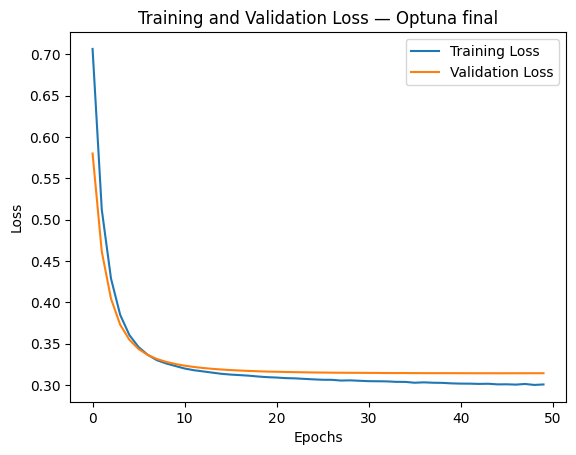

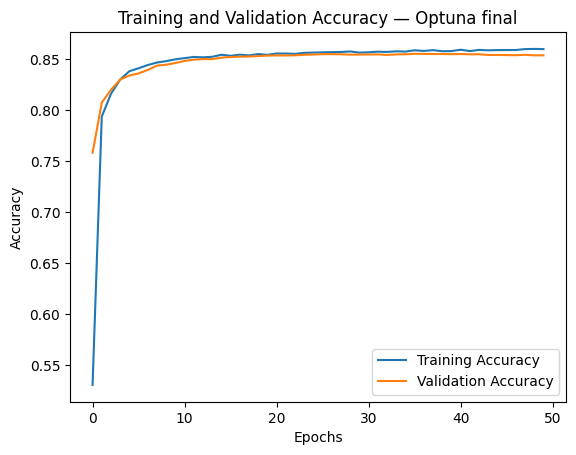

In [29]:
plt.plot(history_final.history["loss"], label="Training Loss")
plt.plot(history_final.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss — Optuna final")
plt.legend()
plt.show()

plt.plot(history_final.history["accuracy"], label="Training Accuracy")
plt.plot(history_final.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy — Optuna final")
plt.legend()
plt.show()


In [30]:
y_pred_prob = best_model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nBest Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Test F1 Score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Test ROC AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))



Best Model Test Set Evaluation:
Test Accuracy: 0.8584
Test Precision: 0.7435
Test Recall: 0.6236
Test F1 Score: 0.6783
Test ROC AUC Score: 0.9120

Classification report:
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.74      0.62      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.79      9769
weighted avg       0.85      0.86      0.85      9769

Confusion matrix:
 [[6928  503]
 [ 880 1458]]


## 6. Conclusions

Preprocessing yields **90 features** (train 39,073 / test 9,769) after dropping `education`, median/`unknown` imputation, and one-hot encoding.

Held-out **test** metrics (accuracy / F1 / ROC AUC):

| Model | Acc | F1 | ROC AUC |
|-------|-----|-----|---------|
| Baseline [64,32], 30 ep | 0.859 | 0.683 | 0.909 |
| Wider [128,128], 10 ep | 0.861 | 0.682 | 0.912 |
| Dropout 0.2, 30 ep | 0.859 | 0.677 | 0.913 |
| Optuna final (1×128 + early stop) | 0.858 | 0.678 | 0.912 |

**Training curves (baseline):** Training accuracy rises to ~0.87 while validation accuracy stays near ~0.85 and validation loss drifts up after ~epoch 10 — mild overfitting if you train the full 30 epochs without early stopping.

**One-factor experiments:** Architecture changes at 10 epochs are small; wider net has the best accuracy. More epochs (50) slightly **hurt** test AUC and raised validation loss (0.317 → 0.340). Dropout **0.2** improved ROC AUC vs no dropout; 0.0 had the lowest accuracy.

**Optuna:** Best validation loss **0.314** (trial 14): one hidden layer with **128** units, learning rate ≈ 2.3×10⁻⁴, batch size 512, dropout ≈ 0.09, negligible L2. On the test set, the final model matches baseline accuracy but improves **ROC AUC** (0.912 vs 0.909) at the cost of slightly lower recall on the positive class.

**Class imbalance:** Precision (~0.74) exceeds recall (~0.63) on the positive class, so accuracy alone overstates performance on high earners; F1 and ROC AUC are the more informative metrics.
